# Evaluation 

## Information Extraction Functions
Define functions that extract the values from simulation output data. 

## Time Delay Impact on DRL Agent (RQ1)

In [40]:
# functions for information extraction
import pandas as pd
import ast
import re

# extract configuration information
def extract_config(lines):
    switch_config_target = "Switch configurations:"
    pctrl_only_target = "'--pctrl-only'"
    data = {}
    found_switch_config = False
    for _, line in enumerate(lines):
        if pctrl_only_target in line:
            pctrl_only_str = line.strip().replace("--", "").split(':')[1].strip()
            pctrl_only = ast.literal_eval(pctrl_only_str)
            data['pctrl_only'] = pctrl_only[0]
        elif switch_config_target in line:
            found_switch_config = True
        elif found_switch_config:
            # Safely evaluate the config string to a Python list containing a dictionary
            item_list = ast.literal_eval(line)
            if isinstance(item_list, list) and len(item_list) > 0 and isinstance(item_list[0], dict):
                record = item_list[0]
                ctrl_id = record.get('ctrl_id')
                thresh = record.get('thresh', {})
                time_delay = thresh.get('time_delay')
                cross_lane_headway = thresh.get('cross_lane_headway')
                data['ctrl_id'] = ctrl_id
                data['time_delay'] = time_delay
                data['cross_lane_headway'] = cross_lane_headway        
            found_switch_config = False  
    return data

# extract delay time
def extract_delay_time(lines):
    target = '--deterministic-delay'
    target2 = '--avg-delay'
    for _, line in enumerate(lines):
        if target in line or target2 in line:
            target_str = line.split(':')[1].replace("'", "").replace(",", "").strip()
            if target_str != "None":
                try: 
                    target_val = float(target_str)
                    return target_val
                except ValueError:
                    print(f"Warning: Could not convert '{target_str}' to floats")
     

# extract switch probabilities
def extract_switch_probs(lines):
    _dict = {}
    for line in lines:
        if line.startswith("[probabilities]"):
            # Use regular expression to find all numbers in the line
            numbers_str = re.findall(r"[-+]?\d*\.\d+|\d+", line)
            if len(numbers_str) >= 2:
                try:
                    #_dict["prob_pri_ctrl"] = float(numbers_str[0])
                    _dict["Sec Ctrl Et (p)"] = 1 - float(numbers_str[0])
                except ValueError:
                    print(f"Warning: Could not convert first two elements to numbers in line: {line.strip()}")
    return _dict

# extract exit probabilities 
def extract_exit_probs(lines):
    _dict = {}
    for line in lines:
        if line.startswith("[counts]"):
            # Use regular expression to find all numbers in the line
            numbers_str = re.findall(r"[-+]?\d*\.\d+|\d+", line)
            if len(numbers_str) >= 3:
                try:
                    num1 = int(numbers_str[1])
                    num2 = int(numbers_str[2])
                    if num1 * num2 < 0 or num1 + num2 <= 0:
                        raise ValueError("Both counts must be non-negative and at least one count must be positive")
                    p = num1 / float(num1 + num2)
                    _dict["Sec Ctrl Ex (p)"] = p
                    #_dict["prob_stay_in_sec_ctrl"] = 1 - p
                except ValueError:
                    print(f"Warning: Could not convert first three elements to numbers in line: {line.strip()}")
    return _dict

def extract_metrics_data_to_df(lines):
    extracted_data = [] 
    for line in lines:
        if line.startswith("[data]"):
                data_part = line[len("[data]"):].strip()
                pairs = data_part.split(', ')
                data_dict = {}
                for pair in pairs:
                    if ':' in pair:
                        key, value = pair.split(': ', 1)
                        data_dict[key.strip()] = value.strip()
                extracted_data.append(data_dict)
    if extracted_data:
        df = pd.DataFrame(extracted_data)
        df['headway'] = df['headway'].astype('float')
        # df['cross_lane_headway'] = df['cross_lane_headway'].astype('float')
        df['ttc'] = df['ttc'].astype('float')
        def bool_str_to_num(x):
            if x=='True':
                return 1  
            else:
                return 0
        df['on lane'] = df['on lane'].apply(bool_str_to_num)
        df = df.drop(['cross_lane_headway'], axis=1)
        return df
    else:
        raise ValueError("Empty data")  # Return an empty DataFrame

In [41]:
import os
# directory of input data for exp 1
current_folder = os.getcwd()
parent_folder = os.path.abspath(os.path.join(current_folder, os.pardir))
input_dir_1 = parent_folder + "/out/highway_env_continuous_actions/experiment/run1"
input_dir_1r = parent_folder + "/out/highway_env_continuous_actions/experiment/run1r"
print(input_dir_1r)

/home/guoxin/PycharmProjects/realtime-drl-switch/scripts/out/highway_env_continuous_actions/experiment/run1r


In [230]:
def generate_time_delay_impacts(input_dir):
    list_of_dfs = []
    for root, _, files in os.walk(input_dir):
            for file in files:
                if file.endswith("log.txt"):
                    file_path = os.path.join(root, file)
                    try:
                        with open(file_path, 'r') as f:
                            lines = f.readlines()   
                            dt = extract_delay_time(lines)           
                            df = extract_metrics_data_to_df(lines)
                            list_of_dfs.append((dt, df))
                    except Exception as e:
                        print(f"Error reading file {file_path}: {e}")
    import pandas as pd
    list_of_dfs.sort(key=lambda item: item[0])
    
    exp_res_list = [];
    for dt, df in list_of_dfs:
        headway_median = df["headway"].median()
        ttc_qt = df["ttc"].quantile(0.1)
        lane_dep_mean = 1 - df["on lane"].mean()
        exp_res_list.append([dt, headway_median, ttc_qt, lane_dep_mean])
    column_names = ["Delay", "Headway (P50)", "TTC (P10)", "Lane Dep (prob)"]
    exp_res = pd.DataFrame(exp_res_list, columns=column_names)
    exp_res = exp_res[['Delay', 'Lane Dep (prob)','TTC (P10)', 'Headway (P50)']]
    return exp_res
print("--deterministic delays--")
print(generate_time_delay_impacts(input_dir_1).round(4).to_string())
print("--randomised delays--")
print(generate_time_delay_impacts(input_dir_1r).round(4).to_string())

--deterministic delays--
    Delay  Lane Dep (prob)  TTC (P10)  Headway (P50)
0    0.00           0.0001    28.0064         4.8403
1    0.05           0.0000    27.8275         4.7022
2    0.10           0.0001    24.9783         4.0851
3    0.15           0.0328    20.6544         4.2097
4    0.20           0.2317    16.8771         4.6250
5    0.25           0.2443    16.5498         4.6607
6    0.30           0.5406    11.7091         4.7424
7    0.35           0.5924     9.5142         4.6305
8    0.40           0.6324     8.7159         4.7036
9    0.45           0.6378     8.8419         4.7278
10   0.50           0.6308     9.2667         5.0252
--randomised delays--
   Delay  Lane Dep (prob)  TTC (P10)  Headway (P50)
0   0.05           0.0003    18.8983         4.3366
1   0.10           0.0063    17.5975         3.8275
2   0.15           0.0354    15.4452         3.7491
3   0.20           0.1152    14.4638         3.9710
4   0.25           0.1923    13.3526         4.1480
5   0

KeyError: 'delay_time'

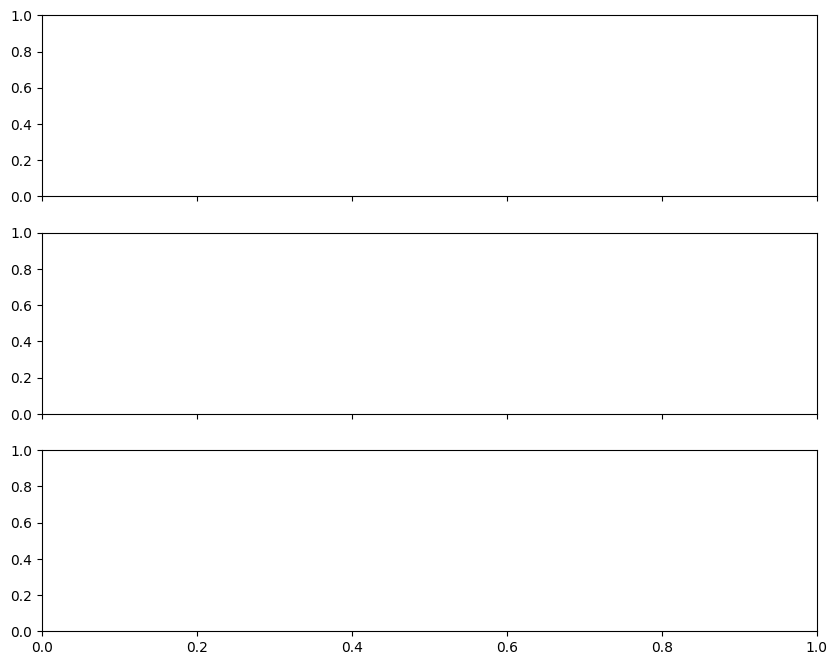

In [43]:
import matplotlib.pyplot as plt
exp1_res = generate_time_delay_impacts(input_dir_1)

# Create a figure and a set of subplots
# 3 rows, 1 column, sharing the x-axis
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(10, 8))

# Plot each column on a different subplot
axes[0].plot(exp1_res['delay_time'], exp1_res['on_lane_prob'], label='On-lane prob.', color='C0') # Use 'C0', 'C1', ... for default colors
axes[1].plot(exp1_res['delay_time'], exp1_res['ttc_10pt'], label='TTC 10 pencentile', color='C1')
axes[2].plot(exp1_res['delay_time'], exp1_res['headway_mean'], label='Avg Headway', color='C2')

# Add titles and labels
axes[0].set_title('On-Lane Probabiilty, TTC and Headway vs. delay') # Main title or set suptitle on fig
axes[0].set_ylabel('')
axes[1].set_ylabel('')
axes[2].set_ylabel('')
axes[2].set_xlabel('Delay time') # Only the bottom subplot needs the x-label

# Add legends to each subplot
axes[0].legend()
axes[1].legend()
axes[2].legend()

# Optional: Add grid
for ax in axes:
    ax.grid(True, linestyle='--', alpha=0.6)

# Improve layout
plt.tight_layout()
# Adjust layout to prevent the suptitle from overlapping the top plot
#fig.suptitle('Data from Columns b, c, and d vs. a (Separate Scales)', y=1.02)

# Show the plot
plt.show()

## Switch Design and Analysis (RQ2)

### Computing thresholds

In [44]:
import os
current_folder = os.getcwd()
parent_folder = os.path.abspath(os.path.join(current_folder, os.pardir))
input_dir_2 = parent_folder + "/out/highway_env_continuous_actions/experiment/run2"
input_dir_2v2 = parent_folder + "/out/highway_env_continuous_actions/experiment/run2v2"

In [46]:
# get headway and ttc thresholds
# no need to get that for on lane (lane depart) probs
#log_pctrl = input_dir_2 + "/20250412_083140/log.txt"
log_pctrl = input_dir_2v2 + "/20251118_012123/log.txt"
try:
    with open (log_pctrl, 'r') as f:
        lines = f.readlines()   
        #dt = extract_delay_time(lines)           
        df_metrics = extract_metrics_data_to_df(lines)
        print("file name: ", log_pctrl)
except Exception as e:
    print(f"Error reading file {log_pctrl}: {e}")
column_names = ["headway_median", "ttc_10pt"]
headway_median = df_metrics["headway"].median()
ttc_qt = df_metrics["ttc"].quantile(0.1)
df_res = pd.DataFrame([[headway_median, ttc_qt]], columns=column_names)
df_res

file name:  /home/guoxin/PycharmProjects/realtime-drl-switch/scripts/out/highway_env_continuous_actions/experiment/run2v2/20251118_012123/log.txt


,headway_median,ttc_10pt
0,3.98555,14.27957


In [53]:
HEADWAY_SCORE = df_res['headway_median'].iloc[0]
TTC_SCORE = df_res['ttc_10pt'].iloc[0]
print(f"HEADWAY_SCORE = {HEADWAY_SCORE}")
print(f"TTC_SCORE = {TTC_SCORE}")

# extract metrics
def generate_metrics_statistics(lines, headway_score=HEADWAY_SCORE, ttc_score=TTC_SCORE):     
    df = extract_metrics_data_to_df(lines)
    n_rows = len(df)
    proportions = {}

    for val3 in [0, 1]:
        for op2 in ['<=', '>']:
            for op1 in ['<=', '>']:
                subset_name = f"HW({op1})&TTC({op2})&OL({val3})"

                condition1 = (df.iloc[:, 0] <= headway_score) if op1 == '<=' else (df.iloc[:, 0] > headway_score)
                condition2 = (df.iloc[:, 1] <= ttc_score) if op2 == '<=' else (df.iloc[:, 1] > ttc_score)
                condition3 = (df.iloc[:, 2] == val3)

                subset = df[condition1 & condition2 & condition3]
                proportions[subset_name] = len(subset) / n_rows if n_rows > 0 else 0.0

    return proportions

def generate_metrics_statistics_v2(lines, headway_score=HEADWAY_SCORE, ttc_score=TTC_SCORE):     
    df = extract_metrics_data_to_df(lines)
    n_rows = len(df)
    proportions = {}
    cond_hw_leq_thd = (df.iloc[:, 0] <= headway_score)
    cond_ttc_leq_thd = (df.iloc[:, 1] <= ttc_score)
    
    proportions['HW (l)'] = len(df[cond_hw_leq_thd]) / n_rows if n_rows > 0 else 0.0
    proportions['TTC (l)'] = len(df[cond_ttc_leq_thd]) / n_rows if n_rows > 0 else 0.0
    #proportions['OL (p)'] = len(df[df.iloc[:, 2] == 1]) / n_rows if n_rows > 0 else 0.0
    proportions['LD (p)'] = len(df[df.iloc[:, 2] == 0]) / n_rows if n_rows > 0 else 0.0

    return proportions

HEADWAY_SCORE = 3.98555
TTC_SCORE = 14.27957


In [229]:
list_of_dicts = []
#directory = input_dir_2
directory = input_dir_2v2
for root, _, files in os.walk(directory):
        for file in files:
            if file.endswith("log.txt"):
                print("file name: ", file)
                file_path = os.path.join(root, file)
                try:
                    with open(file_path, 'r') as f:
                        lines = f.readlines()
                        _dict = extract_config(lines)
                        _dict.update(extract_switch_probs(lines))
                        _dict.update(extract_exit_probs(lines))
                        _dict.update(generate_metrics_statistics_v2(lines))
                        list_of_dicts.append(_dict)
                except Exception as e:
                    print(f"Error reading file {file_path}: {e}")
import pandas as pd
list_of_dicts0 = [x for x in list_of_dicts if x['pctrl_only']==True]
list_of_dicts1 = [x for x in list_of_dicts if x['pctrl_only']==False]
df0 = pd.DataFrame(list_of_dicts0)
df1 = pd.DataFrame(list_of_dicts1)
df_model_params = pd.concat([df0, df1], ignore_index=True)
config = 'config'
new_column_data = ['c0', 'c1', 'c2', 'c3', 'c4']
df_model_params.insert(0, config, new_column_data)
df_model_params = df_model_params.set_index('config')
df_model_params = df_model_params[['pctrl_only', 'ctrl_id','time_delay', 'cross_lane_headway', 
                                   'Sec Ctrl Et (p)', 'Sec Ctrl Ex (p)', 'HW (l)', 'LD (p)', 'TTC (l)']]
df_model_params

file name:  log.txt
file name:  log.txt
file name:  log.txt
file name:  log.txt
file name:  log.txt


,pctrl_only,ctrl_id,time_delay,cross_lane_headway,Sec Ctrl Et (p),Sec Ctrl Ex (p),HW (l),LD (p),TTC (l)
config,,,,,,,,,
c0,True,ctrl_1,0.2,4.0,0.000000,NaN,0.503383,0.115202,0.096876
c1,False,ctrl_1,0.2,4.0,0.389260,0.162232,0.318820,0.164337,0.065796
c2,False,ctrl_1,0.1,4.0,0.606513,0.309623,0.185723,0.174964,0.029723
c3,False,ctrl_2,0.2,4.0,0.389260,0.159471,0.313238,0.163895,0.064111
c4,False,ctrl_2,0.1,4.0,0.606513,0.301184,0.192269,0.174964,0.029443


In [55]:
p1et = df_model_params.loc['c1', 'Sec Ctrl Et (p)']
p2et = df_model_params.loc['c2', 'Sec Ctrl Et (p)']
p3et = df_model_params.loc['c3', 'Sec Ctrl Et (p)']
p4et = df_model_params.loc['c4', 'Sec Ctrl Et (p)']
p1ex = df_model_params.loc['c1', 'Sec Ctrl Ex (p)']
p2ex = df_model_params.loc['c2', 'Sec Ctrl Ex (p)']
p3ex = df_model_params.loc['c3', 'Sec Ctrl Ex (p)']
p4ex = df_model_params.loc['c4', 'Sec Ctrl Ex (p)']
p1hw = df_model_params.loc['c1', 'HW (l)']
p2hw = df_model_params.loc['c2', 'HW (l)']
p3hw = df_model_params.loc['c3', 'HW (l)']
p4hw = df_model_params.loc['c4', 'HW (l)']
p1ttc = df_model_params.loc['c1', 'TTC (l)']
p2ttc = df_model_params.loc['c2', 'TTC (l)']
p3ttc = df_model_params.loc['c3', 'TTC (l)']
p4ttc = df_model_params.loc['c4', 'TTC (l)']
p1ol = 1 - df_model_params.loc['c1', 'LD (p)']
p2ol = 1 - df_model_params.loc['c2', 'LD (p)']
p3ol = 1 - df_model_params.loc['c3', 'LD (p)']
p4ol = 1 - df_model_params.loc['c4', 'LD (p)']

In [151]:
switch_prism_model = \
f"""//Switch model with four configurations for pri and sec controllers 
mdp

const int MAX_TS = 40; // max number of timesteps
const int MIN_CC = 4; // min number of consec calls to a sec contr
//prob to entering sec contr under four confs
const double p1et={p1et}; 
const double p2et={p2et}; 
const double p3et={p3et}; 
const double p4et={p4et}; 
//prob of existing sec contr under four confs (subject to MIN_CC)
const double p1ex={p1ex}; 
const double p2ex={p2ex};
const double p3ex={p3ex};
const double p4ex={p4ex};
//prob of observing low headway
const double p1hw={p1hw};
const double p2hw={p2hw};
const double p3hw={p3hw};
const double p4hw={p4hw};
//prob of observing low ttc
const double p1ttc={p1ttc};
const double p2ttc={p2ttc};
const double p3ttc={p3ttc};
const double p4ttc={p4ttc};
//prob of being on lane
const double p1ol={p1ol};
const double p2ol={p2ol};
const double p3ol={p3ol};
const double p4ol={p4ol};

module BaseSwitch
  
  conf: [0..4]; //four configurations
  sm: [0..2] init 0; //main state variable
  sp: [0..4] init 0; //primary control state varaible
  ss: [0..5] init 0; //secondary control state varaible

  // select configurations 
  [conf] sm=0 -> (sm'=1) & (conf'=1);
  [conf] sm=0 -> (sm'=1) & (conf'=2);
  [conf] sm=0 -> (sm'=1) & (conf'=3);
  [conf] sm=0 -> (sm'=1) & (conf'=4);

  [] sm=1 & (sp=0) & (ss=0) & conf=1 -> (1-p1et) : (sp'=1) + p1et : (ss'=1);
  [] sm=1 & (sp=0) & (ss=0) & conf=2 -> (1-p2et) : (sp'=1) + p2et : (ss'=1);
  [] sm=1 & (sp=0) & (ss=0) & conf=3 -> (1-p3et) : (sp'=1) + p3et : (ss'=1);
  [] sm=1 & (sp=0) & (ss=0) & conf=4 -> (1-p4et) : (sp'=1) + p4et : (ss'=1);

  [obs] sp=1 -> (sp'=2);
  [act_p] sp=2 -> (sp'=3);
  [ex_p] sp=3 -> (sm'=2) & (sp'=0);

  [obs] ss=1 -> (ss'=2);
  [act_s] ss=2 -> (ss'=3);
  [] ss=3 & conf=1 -> (1-p1ex) : (ss'=4) + p1ex : (ss'=5);
  [] ss=3 & conf=2 -> (1-p2ex) : (ss'=4) + p2ex : (ss'=5);
  [] ss=3 & conf=3 -> (1-p3ex) : (ss'=4) + p3ex : (ss'=5);
  [] ss=3 & conf=4 -> (1-p4ex) : (ss'=4) + p4ex : (ss'=5);
  [re_s] ss=4 -> (ss'=1);
  [re_s] ss=5 -> (ss'=1);
  [ex_s] ss=5 -> (sm'=2) & (ss'=0);

  [] sm=2 -> (sm'=0) & (conf'=0);

endmodule

module ConsecCallCounter

  cc: [0..MIN_CC]; //consecutive call counts

  [re_s] cc<MIN_CC -> (cc'=cc+1);
  [re_s] cc=MIN_CC -> (cc'=MIN_CC);
  [ex_s] cc=MIN_CC -> (cc'=0);

endmodule

module HWRecorder
 
  shw: [0..3] init 0; //2: low headway, 3: high headway

  [obs] shw=0 -> (shw'=1);
  [] conf=1 & shw=1 -> p1hw : (shw'=2) + (1-p1hw) : (shw'=3);
  [] conf=2 & shw=1 -> p2hw : (shw'=2) + (1-p2hw) : (shw'=3);
  [] conf=3 & shw=1 -> p3hw : (shw'=2) + (1-p3hw) : (shw'=3);
  [] conf=4 & shw=1 -> p4hw : (shw'=2) + (1-p4hw) : (shw'=3);
  [ex_p] shw=2 -> (shw'=0);
  [ex_s] shw=2 -> (shw'=0);
  [re_s] shw=2 -> (shw'=0);
  [ex_p] shw=3 -> (shw'=0);
  [ex_s] shw=3 -> (shw'=0);
  [re_s] shw=3 -> (shw'=0);

endmodule

module TTCRecorder
 
  sttc: [0..3] init 0; //2: low ttc, 3: high ttc

  [obs] sttc=0 -> (sttc'=1);
  [] conf=1 & sttc=1 -> p1ttc : (sttc'=2) + (1-p1ttc) : (sttc'=3);
  [] conf=2 & sttc=1 -> p2ttc : (sttc'=2) + (1-p2ttc) : (sttc'=3);
  [] conf=3 & sttc=1 -> p3ttc : (sttc'=2) + (1-p3ttc) : (sttc'=3);
  [] conf=4 & sttc=1 -> p4ttc : (sttc'=2) + (1-p4ttc) : (sttc'=3);
  [ex_p] sttc=2 -> (sttc'=0);
  [ex_s] sttc=2 -> (sttc'=0);
  [re_s] sttc=2 -> (sttc'=0);
  [ex_p] sttc=3 -> (sttc'=0);
  [ex_s] sttc=3 -> (sttc'=0);
  [re_s] sttc=3 -> (sttc'=0);

endmodule

module OLRecorder
 
  sol: [0..3] init 0; //2: on lane, 3: not on lane

  [obs] sol=0 -> (sol'=1);
  [] conf=1 & sol=1 -> p1ol : (sol'=2) + (1-p1ol) : (sol'=3);
  [] conf=2 & sol=1 -> p2ol : (sol'=2) + (1-p2ol) : (sol'=3);
  [] conf=3 & sol=1 -> p3ol : (sol'=2) + (1-p3ol) : (sol'=3);
  [] conf=4 & sol=1 -> p4ol : (sol'=2) + (1-p4ol) : (sol'=3);
  [ex_p] sol=2 -> (sol'=0);
  [ex_s] sol=2 -> (sol'=0);
  [re_s] sol=2 -> (sol'=0);
  [ex_p] sol=3 -> (sol'=0);
  [ex_s] sol=3 -> (sol'=0);
  [re_s] sol=3 -> (sol'=0);

endmodule

module TimestepCounter

  tc: [0..MAX_TS] init 0;
  
  //trigger conf and obs only if tc<MAX_TS
  [conf] tc<MAX_TS -> true;
  [obs] tc<MAX_TS -> true;

  //increase timestep counter
  [act_p] tc<MAX_TS -> (tc'=tc+1);
  [act_s] tc<MAX_TS -> (tc'=tc+1);

  //add self-loop to avoid deadlocks
  [] sm<2 & shw=0 & sttc=0 & sol=0 & tc=MAX_TS -> true; 

endmodule

rewards "ctrl_cost"
  [act_p] true : 1/MAX_TS; 
  [act_s] true : 2/MAX_TS; 
endrewards

rewards "headway_cost" // low headway (shw=2) has cost 1/MAX_TS
  [ex_p] shw=2 : 1/MAX_TS; 
  [ex_s] shw=2 : 1/MAX_TS; 
  [re_s] shw=2 : 1/MAX_TS; 
endrewards

rewards "lane_dep_cost" // not on lane (sol=3) has cost 1/MAX_TS
  [ex_p] sol=3 : 1/MAX_TS; 
  [ex_s] sol=3 : 1/MAX_TS; 
  [re_s] sol=3 : 1/MAX_TS; 
endrewards

rewards "ttc_cost" // low ttc (sttc=2) has cost 1/MAX_TS
  [ex_p] sttc=2 : 1/MAX_TS; 
  [ex_s] sttc=2 : 1/MAX_TS; 
  [re_s] sttc=2 : 1/MAX_TS; 
endrewards
"""

In [152]:
with open('switch_model_v2.prism', 'w') as model_file:
    model_file.write(switch_prism_model)

In [77]:
#print(open('switch_model_v2.prism', 'r').read())

In [82]:
f1 = "multi(R{\"ctrl_cost\"}min=?[ C ])"
f2 = "multi(R{\"headway_cost\"}min=?[ C ])"
f3 = "multi(R{\"lane_dep_cost\"}min=?[ C ])"
f4 = "multi(R{\"ttc_cost\"}min=?[ C ])"
print("--single-objective properties--")
with open('safety_metrics.props', 'w') as safety_metrics_file:
    print('file name: "{}"'.format(safety_metrics_file.name))
    safety_metrics_file.write(f1)
    safety_metrics_file.write(';\n')
    safety_metrics_file.write(f2)
    safety_metrics_file.write(';\n')
    safety_metrics_file.write(f3)
    safety_metrics_file.write(';\n')
    safety_metrics_file.write(f4)
print(open('safety_metrics.props', 'r').read())

--single-objective properties--
file name: "safety_metrics.props"
multi(R{"ctrl_cost"}min=?[ C ]);
multi(R{"headway_cost"}min=?[ C ]);
multi(R{"lane_dep_cost"}min=?[ C ]);
multi(R{"ttc_cost"}min=?[ C ])


In [223]:
import os
mopmc_home = os.getenv('MOPMC_HOME') 
storm_home = os.getenv('STORM_HOME') 
prism_home = os.getenv('PRISM_HOME') 
current_dir = os.getcwd()
parent_folder = os.path.abspath(os.path.join(current_folder, os.pardir))
test_model = os.path.join(mopmc_home, 'examples', 'multiobj_scheduler05.nm')
test_property = os.path.join(mopmc_home, 'examples', 'multiobj_scheduler05.pctl')
switch_model = os.path.join(current_dir, 'switch_model_v2.prism')
switch_property = os.path.join(current_dir, 'switch_mo_prop.props')
switch_property2 = os.path.join(current_dir, 'switch_mo_prop2.props')
safety_metrics_property = os.path.join(current_dir, 'safety_metrics.props')
prism_executable = os.path.join(prism_home, 'bin', 'prism')
storm_executable = os.path.join(storm_home, 'build', 'bin', 'storm')
mopmc_executable = os.path.join(mopmc_home, 'build', 'mopmc')
mopmc_export_folder = os.path.join(parent_folder, 'out', 'mopmc_output')

In [224]:
%%time
# Single-objective model checking with Storm
# The optional values of individual objectives can be used as baselines
storm_command_safety_metrics = f"{storm_executable} --prism {switch_model} --prop {safety_metrics_property}"
! $storm_command_safety_metrics

Storm 1.8.2 (dev)

Date: Tue Nov 18 16:08:07 2025
Command line arguments: --prism /home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study/switch_model_v2.prism --prop /home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study/safety_metrics.props
Current working directory: /home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study

Time for model input parsing: 0.002s.

Time for model construction: 0.235s.

-------------------------------------------------------------- 
Model type: 	MDP (sparse)
States: 	92017
Transitions: 	263489
Choices: 	152089
Reward Models:  ttc_cost, lane_dep_cost, headway_cost, ctrl_cost
State Labels: 	2 labels
   * deadlock -> 0 item(s)
   * init -> 1 item(s)
Choice Labels: 	none
-------------------------------------------------------------- 

Model checking property "1": multi(R[exp]{"ctrl_cost"}min=? [C]) ...
Result (for initial states): 1.848471799
Time for model checking: 0.195s.

Model checking property "2": multi(R[exp]{"head

In [225]:
storm_command_safety_metrics2 = f"{storm_executable} --prism {switch_model} --prop {safety_metrics_property2}"
! $storm_command_safety_metrics2

NameError: name 'safety_metrics_property2' is not defined

In [ ]:
%%time
# Single-objective model checking with PRISM
# The optional values of individual objectives can be used as baselines
prism_command_safety_metrics = f"{prism_executable} {switch_model} {safety_metrics_property}"
! $prism_command_safety_metrics

In [222]:
# multi-objective achievability thresholds
ctrl_ma= 1.9
hw_ma = 0.22
ld_ma = 0.169
ttc_ma = 0.035
fma = "multi(R{{\"ctrl_cost\"}}<={}[ C ], R{{\"headway_cost\"}}<={}[ C ], R{{\"lane_dep_cost\"}}<={}[ C ], R{{\"ttc_cost\"}}<={}[ C ])".format(
    ctrl_ma, hw_ma, ld_ma, ttc_ma)
print("--multi-objective property--") 
with open('switch_mo_prop.props', 'w') as property_file:
    print('file name: "{}"'.format(property_file.name))
    property_file.write(fma)
print(open('switch_mo_prop.props', 'r').read())
# multi-objective achievability thresholds
ctrl_ma2= 2.0
hw_ma2 = 0.23
ld_ma2 = 0.174
ttc_ma2 = 0.04
fma2 = "multi(R{{\"ctrl_cost\"}}<={}[ C ], R{{\"headway_cost\"}}<={}[ C ], R{{\"lane_dep_cost\"}}<={}[ C ], R{{\"ttc_cost\"}}<={}[ C ])".format(
    ctrl_ma2, hw_ma2, ld_ma2, ttc_ma2)
print("--multi-objective property--") 
with open('switch_mo_prop2.props', 'w') as property_file:
    print('file name: "{}"'.format(property_file.name))
    property_file.write(fma2)
print(open('switch_mo_prop2.props', 'r').read())

--multi-objective property--
file name: "switch_mo_prop.props"
multi(R{"ctrl_cost"}<=1.9[ C ], R{"headway_cost"}<=0.22[ C ], R{"lane_dep_cost"}<=0.169[ C ], R{"ttc_cost"}<=0.035[ C ])
--multi-objective property--
file name: "switch_mo_prop2.props"
multi(R{"ctrl_cost"}<=2.0[ C ], R{"headway_cost"}<=0.23[ C ], R{"lane_dep_cost"}<=0.174[ C ], R{"ttc_cost"}<=0.04[ C ])


In [226]:
%%time
storm_command_test = f"{storm_executable} --prism {test_model} --prop {test_property}"
storm_command_swtich_model = f"{storm_executable} --prism {switch_model} --prop {switch_property}"
#! $storm_command_test
! $storm_command_swtich_model

Storm 1.8.2 (dev)

Date: Tue Nov 18 16:09:41 2025
Command line arguments: --prism /home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study/switch_model_v2.prism --prop /home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study/switch_mo_prop.props
Current working directory: /home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study

Time for model input parsing: 0.002s.

Time for model construction: 0.236s.

-------------------------------------------------------------- 
Model type: 	MDP (sparse)
States: 	92017
Transitions: 	263489
Choices: 	152089
Reward Models:  ttc_cost, lane_dep_cost, headway_cost, ctrl_cost
State Labels: 	2 labels
   * deadlock -> 0 item(s)
   * init -> 1 item(s)
Choice Labels: 	none
-------------------------------------------------------------- 

Model checking property "1": multi(R[exp]{"ctrl_cost"}<=19/10 [C], R[exp]{"headway_cost"}<=11/50 [C], R[exp]{"lane_dep_cost"}<=169/1000 [C], R[exp]{"ttc_cost"}<=7/200 [C]) ...
Result (for ini

In [227]:
%%time
prism_command_swtich_model2 = f"{prism_executable} {switch_model} {switch_property2}"
! $prism_command_swtich_model2

PRISM
=====

Version: 4.4
Date: Tue Nov 18 16:09:45 AEDT 2025
Hostname: guoxin-Precision-3660
Memory limits: cudd=1g, java(heap)=1g
Command line: prism /home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study/switch_model_v2.prism /home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study/switch_mo_prop2.props

Parsing model file "/home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study/switch_model_v2.prism"...

Parsing properties file "/home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study/switch_mo_prop2.props"...

1 property:
(1) multi(R{"ctrl_cost"}<=2.0 [ C ], R{"headway_cost"}<=0.23 [ C ], R{"lane_dep_cost"}<=0.174 [ C ], R{"ttc_cost"}<=0.04 [ C ])

Type:        MDP
Modules:     BaseSwitch ConsecCallCounter HWRecorder TTCRecorder OLRecorder TimestepCounter 
Variables:   conf sm sp ss cc shw sttc sol tc 

---------------------------------------------------------------------

Model checking: multi(R{"ctrl_cost"}<=2.0 [ C ], R{"headway_co

In [91]:
mopmc_command_test = f"{mopmc_executable} -m {test_model} -p {test_property} -q achievability"
mopmc_achiev_switch_model = f"{mopmc_executable} -m {switch_model} -p {switch_property} -q achievability"
mopmc_convex_switch_model = f"{mopmc_executable} -m {switch_model} -p {switch_property} -q convex -c n -x {mopmc_export_folder}"
mopmc_convex_switch_model_non_exported = f"{mopmc_executable} -m {switch_model} -p {switch_property} -q convex -c n"
mopmc_export_switch_model = f"{mopmc_executable} -m {switch_model} -p {switch_property} -e {mopmc_export_folder}"

In [157]:
%%time
#! $mopmc_command_test
! $mopmc_achiev_switch_model

--Model Building--
States:	92017
Choices:	152089
Transitions:	263489
____ CUDA INITIALIZING ____
____ CUDA EXIT ____
----------------------------------------------
Achievability Query terminates after 3 iteration(s) 
OUTPUT: false
----------------------------------------------
--TIME STATISTICS--
Time for model construction: 0.428 second(s).
Time for data transformation: 0.006 second(s).
Time for model checking: 0.398 second(s), 0.133 per iteration.
Total time: 0.832 second(s).
Main loop count: 3CPU times: user 10.7 ms, sys: 16.1 ms, total: 26.9 ms
Wall time: 1.2 s


In [173]:
! $mopmc_convex_switch_model

--Model Building--
States:	92017
Choices:	152089
Transitions:	263489
____ CUDA INITIALIZING ____
[Main loop] Iteration: 0
[Project gradient - interior phase] finds minimum point at iteration: 3 (distance: 0)
[Minimum norm point optimization] exits for one vertex
[Main loop] Iteration: 1
[Main loop] Iteration: 2
[Project gradient - interior phase] finds minimum point at iteration: 2 (distance: 0)
[Minimum norm point optimization] max margin separation hyperplane computed, terminates at iteration: 2 (distance: 0.0001275962463)
[Main loop] Iteration: 3
[Main loop] Iteration: 4
[Project gradient - interior phase] finds minimum point at iteration: 2 (distance: 0)
[Minimum norm point optimization] max margin separation hyperplane computed, terminates at iteration: 7 (distance: 6.471041873e-06)
[Main loop] Iteration: 5
[Main loop] Iteration: 6
[Project gradient - interior phase] finds minimum point at iteration: 2 (distance: 3.770968991e-06)
[Minimum norm point optimization] max margin separa

In [174]:
! $mopmc_export_switch_model

--Model Building--
States:	92017
Choices:	152089
Transitions:	263489
Successfully wrote state map to "/home/guoxin/PycharmProjects/realtime-drl-switch/scripts/out/mopmc_output/states.txt", 92018 lines in total
Successfully wrote transition matrix to "/home/guoxin/PycharmProjects/realtime-drl-switch/scripts/out/mopmc_output/transition_matrix.txt", 263490 lines in total


In [ ]:
! $mopmc_convex_switch_model_non_exported

In [175]:
f0_1 = "multi(R{\"ctrl_cost\"}<=1.883 [ C ], R{\"headway_cost\"}<=0.573[ C ], R{\"ttc_cost\"}<=0.235[ C ], R{\"onlane_cost\"}<=0.235[ C ])"
with open('switch_mo_acheivable_prop.props', 'w') as property_file_1:
    property_file_1.write(f0_1)
print("--multi-objective property--") 
print(open('switch_mo_acheivable_prop.props', 'r').read())
switch_acheivable_property = os.path.join(current_dir, 'switch_mo_acheivable_prop.props')
storm_command_swtich_model2 = f"{storm_executable} --prism {switch_model} --prop {switch_acheivable_property}"
prism_command_swtich_model2 = f"{prism_executable} {switch_model} {switch_acheivable_property}"

--multi-objective property--
multi(R{"ctrl_cost"}<=1.883 [ C ], R{"headway_cost"}<=0.573[ C ], R{"ttc_cost"}<=0.235[ C ], R{"onlane_cost"}<=0.235[ C ])


In [176]:
#! $storm_command_swtich_model2

In [177]:
#! $prism_command_swtich_model2

In [178]:
import pandas as pd
import os
states_path = os.path.join(mopmc_export_folder, "states.txt")
df_states = pd.read_csv(states_path, sep='\t', header=0)
#df_states_non_det = df_states[df_states['non-deterministic'] == 'y'].copy()
df_states_non_det = df_states_non_det[df_states_non_det['expression'].str.contains('conf=0')]
#print(df_states_non_det.head())
#! head ./out/mopmc_output/states.txt
df_states_non_det.count()


state_id             40
expression           40
non-deterministic    40
dtype: int64

In [179]:
trans_path = os.path.join(mopmc_export_folder, "transition_matrix.txt")
df_trans = pd.read_csv(trans_path, sep='\t', header=0)
schedulers_path = os.path.join(mopmc_export_folder, "schedulers.txt")
df_schedulers = pd.read_csv(schedulers_path, sep='\t', dtype={'scheduler': int, 'state': int, 'action': int})
sch_dist_path = os.path.join(mopmc_export_folder, "scheduler_distribution.txt")
df_sch_dist = pd.read_csv(sch_dist_path, sep='\t', header=0, dtype={'scheduler_id': int, 'probability': float})
# df_schedulers

In [180]:
threshold = 0.01
df_sch_dist1 = df_sch_dist[df_sch_dist['probability'] >= threshold].copy()
sum_filtered_probabilities = df_sch_dist1['probability'].sum()
df_sch_dist1['probability'] = df_sch_dist1['probability'] / sum_filtered_probabilities
df_sch_dist1 
#df_sch_dist

,scheduler_id,probability
1,1,0.329466
3,3,0.112003
5,5,0.041668
7,7,0.121635
9,9,0.395228


In [181]:
df_schedulers_states_non_det = pd.merge(
    df_schedulers, df_states_non_det, left_on='state', right_on='state_id', how = 'inner')
df_schedulers_all = pd.merge(df_sch_dist1, df_schedulers_states_non_det, left_on='scheduler_id', right_on='scheduler', how = 'inner')
df_schedulers_all.drop(labels=['scheduler_id', 'state_id', 'state', 'non-deterministic'], axis=1, inplace=True)

def action_to_configuration(action):
    if action == 0:
        return 'c1' 
    elif action == 1:
        return 'c2'
    elif action == 2:
        return 'c3'
    elif action == 3:
        return 'c4'
    else:
        return None
df_schedulers_all['configuration'] = df_schedulers_all['action'].apply(action_to_configuration)
df_schedulers_all.drop(labels=['action'], axis=1, inplace=True)
df_schedulers_all.rename(columns={'expression': 'state expression'}, inplace=True)
pd.set_option('display.max_colwidth', None)
df_schedulers_all.head()
#print(df_schedulers_all.head())

,probability,scheduler,state expression,configuration
0,0.329466,1,conf=0 & sm=0 & sp=0 & ss=0 & cc=0 & shw=0 & sttc=0 & sol=0 & tc=0,c2
1,0.329466,1,conf=0 & sm=0 & sp=0 & ss=0 & cc=0 & shw=0 & sttc=0 & sol=0 & tc=1,c2
2,0.329466,1,conf=0 & sm=0 & sp=0 & ss=0 & cc=0 & shw=0 & sttc=0 & sol=0 & tc=2,c2
3,0.329466,1,conf=0 & sm=0 & sp=0 & ss=0 & cc=0 & shw=0 & sttc=0 & sol=0 & tc=3,c2
4,0.329466,1,conf=0 & sm=0 & sp=0 & ss=0 & cc=0 & shw=0 & sttc=0 & sol=0 & tc=4,c2


In [183]:
weighted_frequencies = df_schedulers_all.groupby('configuration')['probability'].sum()
weighted_frequencies[0]
total_sum = weighted_frequencies.sum()
normalised_frequencies = weighted_frequencies / total_sum
result_df = normalised_frequencies.reset_index(name='selection probability')
result_df
#	c1	0.112003
#	c2	0.329466
#	c3	0.121635
#	c4	0.436896

,configuration,selection probability
0,c1,0.112003
1,c2,0.329466
2,c3,0.121635
3,c4,0.436896


### Other Models

In [193]:
switch_model_c1 = os.path.join(current_dir, 'switch_model_c1_v2.prism')
switch_model_c2 = os.path.join(current_dir, 'switch_model_c2_v2.prism')
switch_model_c3 = os.path.join(current_dir, 'switch_model_c3_v2.prism')
switch_model_c4 = os.path.join(current_dir, 'switch_model_c4_v2.prism')
metrics_single_objectives = os.path.join(current_dir, 'safety_metrics_single_objectives.props')
storm_command_swtich_model_c1 = f"{storm_executable} --prism {switch_model_c1} --prop {metrics_single_objectives}"
storm_command_swtich_model_c2 = f"{storm_executable} --prism {switch_model_c2} --prop {metrics_single_objectives}"
storm_command_swtich_model_c3 = f"{storm_executable} --prism {switch_model_c3} --prop {metrics_single_objectives}"
storm_command_swtich_model_c4 = f"{storm_executable} --prism {switch_model_c4} --prop {metrics_single_objectives}"
#! $storm_command_swtich_model_c1

Storm 1.8.2 (dev)

Date: Tue Nov 18 15:05:27 2025
Command line arguments: --prism /home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study/switch_model_c1_v2.prism --prop /home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study/safety_metrics_single_objectives.props
Current working directory: /home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study

Time for model input parsing: 0.002s.

Time for model construction: 0.069s.

-------------------------------------------------------------- 
Model type: 	MDP (sparse)
States: 	23035
Transitions: 	65873
Choices: 	38023
Reward Models:  ttc_cost, lane_dep_cost, headway_cost, ctrl_cost
State Labels: 	2 labels
   * deadlock -> 0 item(s)
   * init -> 1 item(s)
Choice Labels: 	none
-------------------------------------------------------------- 

Model checking property "1": R[exp]{"ctrl_cost"}min=? [C] ...
Result (for initial states): 1.848471799
Time for model checking: 0.031s.

Model checking property "2": R[exp]

In [217]:
import os
import re
import subprocess
import pandas as pd

switch_model_c1 = os.path.join(current_dir, 'switch_model_c1_v2.prism')
switch_model_c2 = os.path.join(current_dir, 'switch_model_c2_v2.prism')
switch_model_c3 = os.path.join(current_dir, 'switch_model_c3_v2.prism')
switch_model_c4 = os.path.join(current_dir, 'switch_model_c4_v2.prism')
switch_model_unif = os.path.join(current_dir, 'switch_model_c1_to_c4_unif_v2.prism')

metrics_single_objectives = os.path.join(current_dir, 'safety_metrics_single_objectives.props')

# Create a list of configurations and their corresponding command strings
configurations = ['c1', 'c2', 'c3', 'c4', 'unif']
model_files = [switch_model_c1, switch_model_c2, switch_model_c3, switch_model_c4, switch_model_unif]

commands = [
    f"{storm_executable} --prism {model} --prop {metrics_single_objectives}"
    for model in model_files
]

# Regular Expression (Fixed to capture the metric name and result)
# Captures the string inside {"..."} and the result number
pattern = r'\{"([^"]+)"\}[\s\S]*?Result \(for initial states\): (\d+\.?\d*)'

# List to hold the single-row DataFrame results for each configuration
all_results = []

# --- Loop Execution and Data Extraction ---
print("Starting model checking process...")

for config, command_string in zip(configurations, commands):
    try:
        # Execute the command and capture the output
        result = subprocess.run(
            command_string.split(),
            capture_output=True,
            text=True,
            check=True
        )
        output_string = result.stdout
        
        # Extract data using the fixed regex
        extracted_data = re.findall(pattern, output_string)
        
        # Prepare data for the single-row DataFrame
        column_names = [item[0] for item in extracted_data]
        column_values = [float(item[1]) for item in extracted_data]
        
        # Create a single-row DataFrame for the current configuration
        # Add a column for the configuration name
        row_data = {'Configuration': [config]}
        
        # Add the metric results to the row data dictionary
        for name, value in zip(column_names, column_values):
            row_data[name] = [value]
            
        df_row = pd.DataFrame(row_data)
        
        # Append the single-row DataFrame to the list
        all_results.append(df_row)
        print(f"✅ Successfully processed {config}")

    except subprocess.CalledProcessError as e:
        print(f"❌ Error processing {config}: Command failed with error code {e.returncode}")
        print(f"Stderr: {e.stderr}")
    except FileNotFoundError:
        print(f"❌ Error: Storm executable or model files not found for {config}. Check paths.")
        
print("Model checking complete.")
# --- Final DataFrame Consolidation ---

if all_results:
    final_df = pd.concat(all_results, ignore_index=True)
    
    # Reorder columns to put 'Configuration' first
    cols = ['Configuration'] + [col for col in final_df.columns if col != 'Configuration']
    final_df = final_df[cols]
    
    print("\n--- Final Results DataFrame ---")
    print(final_df.round(4))
else:
    print("\nNo results were successfully processed to create the final DataFrame.")

Starting model checking process...
✅ Successfully processed c1
✅ Successfully processed c2
✅ Successfully processed c3
✅ Successfully processed c4
✅ Successfully processed unif
Model checking complete.

--- Final Results DataFrame ---
  Configuration  ctrl_cost  headway_cost  lane_dep_cost  ttc_cost
0            c1     1.8485        0.3188         0.1643    0.0658
1            c2     1.9108        0.1857         0.1750    0.0297
2            c3     1.8495        0.3132         0.1639    0.0641
3            c4     1.9117        0.1923         0.1750    0.0294
4          unif     1.8815        0.2117         0.1671    0.0359


In [212]:
import subprocess
storm_command_swtich_model_c1 = f"{storm_executable} --prism {switch_model_c1} --prop {metrics_single_objectives}"
# Execute the command and capture the output
result = subprocess.run(
    storm_command_swtich_model_c1.split(),
    capture_output=True,  # Capture stdout and stderr
    text=True,            # Decode stdout/stderr as text (string)
    check=True            # Raise an exception if the command returns a non-zero exit code
)
output_string = result.stdout
pattern = r'\{"([^"]+)"\}[\s\S]*?Result \(for initial states\): (\d+\.?\d*)'
extracted_data = re.findall(pattern, output_string)
column_names = [item[0] for item in extracted_data]
column_values = [float(item[1]) for item in extracted_data]
data_dict = dict(zip(column_names, [column_values]))
results_df = pd.DataFrame([column_values], columns=column_names)
results_df.round(4)
#print(results_df.round(4))

,ctrl_cost,headway_cost,lane_dep_cost,ttc_cost
0,1.8485,0.3188,0.1643,0.0658


In [198]:
captured_output_string = result.stdout

print(captured_output_string)

Storm 1.8.2 (dev)

Date: Tue Nov 18 15:22:42 2025
Command line arguments: --prism /home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study/switch_model_c1_v2.prism --prop /home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study/safety_metrics_single_objectives.props
Current working directory: /home/guoxin/PycharmProjects/realtime-drl-switch/scripts/case_study

Time for model input parsing: 0.011s.

Time for model construction: 0.080s.

-------------------------------------------------------------- 
Model type: 	MDP (sparse)
States: 	23035
Transitions: 	65873
Choices: 	38023
Reward Models:  ttc_cost, lane_dep_cost, headway_cost, ctrl_cost
State Labels: 	2 labels
   * deadlock -> 0 item(s)
   * init -> 1 item(s)
Choice Labels: 	none
-------------------------------------------------------------- 

Model checking property "1": R[exp]{"ctrl_cost"}min=? [C] ...
Result (for initial states): 1.848471799
Time for model checking: 0.016s.

Model checking property "2": R[exp]

In [228]:
import numpy as np
np.sqrt(5.123382087e-06)

0.0022634889191246333